# Домашнее задание 2. Выпуклость и множители Лагранжа

**Выдано:** 23 сентября 2026 (обновлено 29 сентября). **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)) — операции, сохраняющие выпуклость (раздел 5), чек-лист выпуклой задачи (раздел 6), условие оптимальности (раздел 7); лекция 3 ([конспект](../lectures/lecture03/lecture03.md)) — баланс сил $\nabla f = \mu \nabla h$, касание $\nabla f = \lambda \nabla g$, функция Лагранжа и множитель как цена (разделы 4–8). Ничего сверх лекций не требуется. Ориентировочное время — 4–5 часов.

**Сложность** отмечена звёздочками: ★ — разминка, ★★ — стандартная задача, ★★★ — нужно подумать. Большая часть задания решается на бумаге; код нужен в задаче 3 и для коротких проверок.

| Задача | Баллы | О чём |
|--------|-------|-------|
| 1. Выпуклость | 3 | множества, критерий второго порядка, операции |
| 2. Три функции | 2 | функция Розенброка, log-sum-exp, наибольшее собственное число |
| 3. Выпуклая и невыпуклая подгонка | 2 | синус с неизвестной и известной частотой, мультистарт |
| 4. Множители Лагранжа | 3 | проекция на полупространство, собственные числа как касание, «водозаполнение» |
| Бонус | +1 | максимум энтропии и распределение Больцмана |

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
from scipy.special import logsumexp

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (3 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества** ★. Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка** ★.

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции** ★★. Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(а)**

**Ответ:**

1. Множество выпукло.
   
   Это множество — надграфик функции $f(x_1) = x_1^2$. Надграфик выпукл тогда и только тогда, когда функция выпукла. Функция выпукла по критерию второго порядка ($f''(x_1) = 2 \ge 0$), а значит выпукло и множество.
   
2. Множество выпукло.

   Шар $B = \{z \in \mathbb{R}^m : \Vert z\Vert_2 \le 1\}$ выпукл. Это множество — его аффинный прообраз: $\{x : Ax - b \in B\}$. Аффинный прообраз выпуклого множества выпукл. Это верно при любых $A$, $b$, в том числе при вырожденной $A$: тогда множество не ограничено, но выпукло.

   
3. Множество не выпукло.

   Точки $x = (1, 0)$ и $y = (-1, 0)$ лежат в множестве ($\Vert x\Vert = \Vert y\Vert = 1$), а середина отрезка $\tfrac12 x + \tfrac12 y = (0, 0)$ имеет норму $0 < 1$ и в множество не входит.

**(б)**

**Ответ:**

1. Функция выпукла при $|a| \le 2$, строго выпукла при $|a| < 2$.

    $$\nabla^2 f = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}.$$

    Гессиан не зависит от $x$, поэтому достаточно проверить одну матрицу. Функция квадратичная, и для неё по критерию второго порядка $f$ выпукла $\iff \nabla^2 f \succeq 0$ и строго выпукла $\iff \nabla^2 f \succ 0$.

    Собственные числа $\nabla^2 f$ находим из $\det(\nabla^2 f - \lambda I) = (2 - \lambda)^2 - a^2 = 0$: они равны $2 \pm a$. Значит, $\nabla^2 f \succeq 0 \iff |a| \le 2$, а $\nabla^2 f \succ 0 \iff |a| < 2$.

2. Функция не выпукла.

    $$\nabla^2 g = \begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix}, \qquad \det \nabla^2 g = 4x_1^2x_2^2 - 16x_1^2x_2^2 = -12\,x_1^2x_2^2 .$$

    По критерию второго порядка достаточно одной точки, где гессиан не полуопределён. При $x_1x_2 \ne 0$ определитель отрицателен, значит собственные числа разных знаков. Например, в $(1, 1)$ гессиан $\begin{pmatrix} 2 & 4 \\ 4 & 2 \end{pmatrix}$ имеет собственные числа $6$ и $-2$.

In [2]:
for a in [-3, -2, -1, 0, 1, 2, 3]:
    print(f"a = {a:2d}: собственные числа гессиана f", np.linalg.eigvalsh(np.array([[2.0, a], [a, 2.0]])))

print("\nгессиан g в (1, 1):", np.linalg.eigvalsh(np.array([[2.0, 4.0], [4.0, 2.0]])))
g = lambda x: x[0] ** 2 * x[1] ** 2
print("g(1,0) =", g([1, 0]), " g(0,1) =", g([0, 1]), " g(середины) =", g([0.5, 0.5]))

a = -3: собственные числа гессиана f [-1.  5.]
a = -2: собственные числа гессиана f [0. 4.]
a = -1: собственные числа гессиана f [1. 3.]
a =  0: собственные числа гессиана f [2. 2.]
a =  1: собственные числа гессиана f [1. 3.]
a =  2: собственные числа гессиана f [0. 4.]
a =  3: собственные числа гессиана f [-1.  5.]

гессиан g в (1, 1): [-2.  6.]
g(1,0) = 0  g(0,1) = 0  g(середины) = 0.0625


**(в)**

**Ответ:**

1. Функция выпукла.

    $\Vert Ax - b\Vert_2$ — норма от аффинного отображения, она выпукла. $\Vert x\Vert_\infty$ — норма, она тоже выпукла. Сумма выпуклых функций с неотрицательными весами выпукла, а $\lambda \ge 0$.

2. Функция выпукла.

    $(a_i^\top x - b_i)^2$ — выпуклая функция $u^2$ от аффинной $u = a_i^\top x - b_i$, поэтому она выпукла. Поточечный максимум выпуклых функций выпукл.

3. Функция не выпукла.

    Правило композиции здесь не применяется: $e^u$ выпукла и не убывает, но внутренняя функция $-\Vert x\Vert_2^2$ не выпукла, а вогнута. Контрпример на прямой $x = s e_1$: $f = e^{-s^2}$, $f(\pm 1) = e^{-1}$, а в середине $f(0) = 1 > e^{-1}$.

Гладкая только функция 3. В функции 1 $\Vert Ax - b\Vert_2$ не дифференцируема там, где $Ax = b$, а $\Vert x\Vert_\infty$ — там, где наибольший модуль достигается на нескольких координатах. В функции 2 излом там, где максимум достигается сразу на двух слагаемых с разными градиентами.

## Задача 2. Три функции (2 балла)

**(а) Функция Розенброка** ★ (0.5 балла). $f(x) = (1 - x_1)^2 + 100\,(x_2 - x_1^2)^2$ — «банановая долина», на которой в части II будем испытывать все методы.

1. Докажите, что $f$ не выпукла: предъявите хорду, лежащую под графиком, или точку, где гессиан не полуопределён.
2. Найдите множество точек, где $\nabla^2 f(x) \succeq 0$. Как оно расположено относительно дна долины $x_2 = x_1^2$?
3. Найдите все стационарные точки $f$. Почему у этой невыпуклой функции единственный локальный минимум оказался глобальным и не противоречит ли это лекции 2?

**(б) Гладкий максимум: log-sum-exp** ★★ (0.75 балла). $\operatorname{lse}(x) = \log \sum_{i=1}^n e^{x_i}$, $x \in \mathbb{R}^n$.

1. Докажите, что $\max_i x_i \le \operatorname{lse}(x) \le \max_i x_i + \log n$.
2. Для $t > 0$ положим $\operatorname{lse}_t(x) = \tfrac1t \operatorname{lse}(t x)$. Покажите, что $\operatorname{lse}_t(x) \to \max_i x_i$ при $t \to \infty$, и оцените погрешность.
3. Вычислите градиент и гессиан $\operatorname{lse}$ и докажите, что $\operatorname{lse}$ выпукла. Подсказка: обозначьте $p_i = e^{x_i} / \sum_j e^{x_j}$ и сведите $v^\top \nabla^2 \operatorname{lse}(x)\, v \ge 0$ к неравенству Коши–Буняковского (или к неотрицательности дисперсии). Строго ли она выпукла?
4. Проверьте оценку из пункта 2 численно для случайного $x \in \mathbb{R}^{10}$ с координатами порядка $10$ и $t = 1, 10, 100$. Посчитайте $\operatorname{lse}$ «в лоб», `np.log(np.sum(np.exp(t * x))) / t`, и через `scipy.special.logsumexp`. Что ломается при $t = 100$ и как `logsumexp` этого избегает?

Зачем это нужно: $\max$ выпукл, но негладок, а $\operatorname{lse}_t$ — его гладкая выпуклая замена сверху. Так, например, сглаживают чебышёвскую подгонку из бонуса ДЗ 1.

**(в) Наибольшее собственное число** ★★★ (0.75 балла). $\mathbb{S}^n$ — пространство симметричных матриц $n \times n$, у $X \in \mathbb{S}^n$ собственные числа $\lambda_1(X) \ge \dots \ge \lambda_n(X)$.

1. Докажите, что $\lambda_1(X) = \max_{\Vert v\Vert = 1} v^\top X v$, и выведите отсюда, что $\lambda_1$ — выпуклая функция на $\mathbb{S}^n$, а $\lambda_n$ — вогнутая. Подсказка: при фиксированном $v$ отображение $X \mapsto v^\top X v$ линейно по $X$.
2. Выпукло ли множество положительно полуопределённых матриц $\{X \in \mathbb{S}^n : X \succeq 0\}$? А множество $\{X : \lambda_1(X) \le 1\}$?
3. Выпукла или вогнута на $\mathbb{S}^3$ функция $\lambda_2(X)$ — второе по величине собственное число? Достаточно диагональных матриц.

**(а)**

**Ответ:**

$$\nabla f = \begin{pmatrix} -2(1 - x_1) - 400x_1(x_2 - x_1^2) \\ 200(x_2 - x_1^2) \end{pmatrix}, \qquad \nabla^2 f = \begin{pmatrix} 2 - 400x_2 + 1200x_1^2 & -400x_1 \\ -400x_1 & 200 \end{pmatrix}.$$

1. Функция не выпукла.

    В точке $(0, 1)$ гессиан равен $\operatorname{diag}(-398,\ 200)$ и не полуопределён.

2. Гессиан полуопределён при $x_2 \le x_1^2 + 0.005$.

    $f_{22} = 200 > 0$, поэтому $\nabla^2 f \succeq 0 \iff \det \nabla^2 f \ge 0$ (тогда и $f_{11} \ge 0$):

    $$\det \nabla^2 f = 200(2 - 400x_2 + 1200x_1^2) - 160000x_1^2 = 400 - 80000\,(x_2 - x_1^2) \ge 0 \iff x_2 \le x_1^2 + 0.005 .$$

    Это всё, что ниже дна долины $x_2 = x_1^2$, само дно и узкая полоска шириной $0.005$ над ним. Выше долины гессиан не полуопределён (красная область на картинке ниже).

3. Стационарная точка одна — $(1, 1)$, это глобальный минимум.

    Из $\partial f/\partial x_2 = 0$ получаем $x_2 = x_1^2$, тогда $\partial f/\partial x_1 = -2(1 - x_1) = 0$ и $x_1 = 1$. $f(1, 1) = 0$, а $f \ge 0$ как сумма квадратов, значит это глобальный минимум.

    Противоречия с лекцией нет. Там доказано, что у выпуклой функции локальный минимум глобальный. Это достаточное условие, а не необходимое: у невыпуклой функции локальный минимум тоже может быть глобальным. Здесь это следует из $f \ge 0$.

собственные числа гессиана в (0, 1): [-398.  200.]
собственные числа гессиана в (1, 1): [3.99360767e-01 1.00160064e+03]


совпадает с формулой на сетке: True


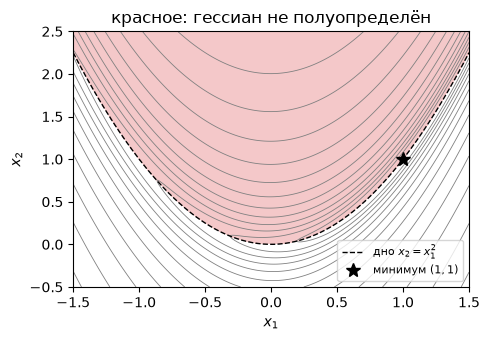

In [3]:
def hess_rosen(x1, x2):
    return np.array([[2 - 400 * x2 + 1200 * x1**2, -400 * x1], [-400 * x1, 200.0]])

print("собственные числа гессиана в (0, 1):", np.linalg.eigvalsh(hess_rosen(0.0, 1.0)))
print("собственные числа гессиана в (1, 1):", np.linalg.eigvalsh(hess_rosen(1.0, 1.0)))

# сверка границы x2 = x1^2 + 0.005 с прямым вычислением собственных чисел на сетке
X1, X2 = np.meshgrid(np.linspace(-1.5, 1.5, 301), np.linspace(-0.5, 2.5, 301))
psd = np.vectorize(lambda a, b: np.linalg.eigvalsh(hess_rosen(a, b))[0] >= 0)(X1, X2)
print("совпадает с формулой на сетке:", np.array_equal(psd, X2 <= X1**2 + 0.005))

F = (1 - X1) ** 2 + 100 * (X2 - X1**2) ** 2
plt.figure(figsize=(5, 3.5))
plt.contourf(X1, X2, ~psd, levels=[0.5, 1.5], colors=["tab:red"], alpha=0.25)
plt.contour(X1, X2, np.log1p(F), levels=15, colors="0.5", linewidths=0.6)
plt.plot(X1[0], X1[0] ** 2, "k--", lw=1, label="дно $x_2 = x_1^2$")
plt.plot(1, 1, "k*", ms=10, label="минимум $(1, 1)$")
plt.ylim(-0.5, 2.5); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(fontsize=8, loc="lower right")
plt.title("красное: гессиан не полуопределён")
plt.tight_layout(); plt.show()

**(б)**

**Ответ:**

1. Обе оценки получаются из оценки суммы через наибольшее слагаемое.

    Пусть $M = \max_i x_i$. В сумме $\sum_i e^{x_i}$ есть слагаемое $e^M$, а каждое слагаемое не больше $e^M$:

    $$e^M \le \sum_i e^{x_i} \le n e^M .$$

    Логарифм возрастает, поэтому $M \le \operatorname{lse}(x) \le M + \log n$.

2. $\operatorname{lse}_t(x) \to \max_i x_i$, погрешность не больше $\log n / t$.

    Применим пункт 1 к $tx$: $\max_i tx_i = tM$, поэтому $tM \le \operatorname{lse}(tx) \le tM + \log n$. Делим на $t > 0$:

    $$0 \le \operatorname{lse}_t(x) - \max_i x_i \le \frac{\log n}{t} \to 0 .$$

3. Функция выпукла, но не строго.

    $\partial \operatorname{lse}/\partial x_i = e^{x_i}/\sum_j e^{x_j} = p_i$, то есть $\nabla \operatorname{lse} = p$. Дальше $\partial p_i/\partial x_j = p_i\delta_{ij} - p_ip_j$:

    $$\nabla^2 \operatorname{lse} = \operatorname{diag}(p) - pp^\top, \qquad v^\top \nabla^2 \operatorname{lse}\, v = \sum_i p_i v_i^2 - \Big(\sum_i p_i v_i\Big)^2 .$$

    По Коши–Буняковскому с учётом $\sum_i p_i = 1$: $\big(\sum_i \sqrt{p_i}\cdot\sqrt{p_i}\,v_i\big)^2 \le \sum_i p_i \cdot \sum_i p_i v_i^2 = \sum_i p_i v_i^2$. Значит, $\nabla^2 \operatorname{lse} \succeq 0$, и по критерию второго порядка функция выпукла.

    Строгой выпуклости нет: при $v = \mathbf 1$ получается $1 - 1 = 0$. И действительно, $\operatorname{lse}(x + c\mathbf 1) = \operatorname{lse}(x) + c$, вдоль $\mathbf 1$ функция линейна.

4. При $t = 100$ счёт «в лоб» даёт `inf`, а `logsumexp` считает правильно.

    Оценка из пункта 2 выполняется (ячейка ниже): при $t = 1$ погрешность $5 \cdot 10^{-4}$ при границе $2.3$, при $t = 10$ и $100$ погрешность нулевая в машинной точности.

    При $t = 100$ показатели доходят до $100 \cdot 14 = 1400$, а $e^{1400}$ не помещается в `float64` (предел около $e^{709}$), получается `inf`. `logsumexp` выносит максимум: $\operatorname{lse}(z) = m + \log\sum_i e^{z_i - m}$, где $m = \max_i z_i$. Все показатели $\le 0$, одно слагаемое равно $1$, поэтому сумма лежит в $[1, n]$ и не переполняется.

In [4]:
x = 10 * rng.standard_normal(10)
print("max x =", x.max())
for tt in [1, 10, 100]:
    with np.errstate(over="ignore"):
        naive = np.log(np.sum(np.exp(tt * x))) / tt
    stable = logsumexp(tt * x) / tt
    print(f"t = {tt:3d}: в лоб {naive:.6f}, logsumexp {stable:.6f}, "
          f"погрешность {stable - x.max():.1e} <= log(n)/t = {np.log(x.size) / tt:.1e}")

max x = 13.957717101086942
t =   1: в лоб 13.958258, logsumexp 13.958258, погрешность 5.4e-04 <= log(n)/t = 2.3e+00
t =  10: в лоб 13.957717, logsumexp 13.957717, погрешность 0.0e+00 <= log(n)/t = 2.3e-01
t = 100: в лоб inf, logsumexp 13.957717, погрешность 0.0e+00 <= log(n)/t = 2.3e-02


**(в)**

**Ответ:**

1. $\lambda_1(X) = \max_{\Vert v\Vert = 1} v^\top X v$, поэтому $\lambda_1$ выпукла, а $\lambda_n$ вогнута.

    Разложим $X = Q\Lambda Q^\top$, где $Q$ ортогональная, а её столбцы $q_i$ — собственные векторы. Для $\Vert v\Vert = 1$ положим $w = Q^\top v$, тогда $\Vert w\Vert = 1$ и

    $$v^\top X v = \sum_i \lambda_i w_i^2 \le \lambda_1 \sum_i w_i^2 = \lambda_1 .$$

    Равенство достигается при $v = q_1$.

    При фиксированном $v$ функция $X \mapsto v^\top X v$ линейна по $X$. Поточечный максимум линейных функций выпукл, значит $\lambda_1$ выпукла. Так же $\lambda_n(X) = \min_{\Vert v\Vert = 1} v^\top X v$ — минимум линейных функций, она вогнута.

2. Оба множества выпуклы.

    $\{X \succeq 0\} = \{X : \lambda_n(X) \ge 0\}$ — множество, где вогнутая функция не меньше нуля, оно выпукло. $\{X : \lambda_1(X) \le 1\}$ — подуровневое множество выпуклой функции, оно тоже выпукло.

3. $\lambda_2$ ни выпукла, ни вогнута.

    Для диагональной матрицы собственные числа — это её диагональ, а $\lambda_2$ — медиана диагонали. Возьмём $X = \operatorname{diag}(1, 0, 0)$ и $Y = \operatorname{diag}(0, 1, 0)$: $\lambda_2(X) = \lambda_2(Y) = 0$, а у середины $\operatorname{diag}(\tfrac12, \tfrac12, 0)$ $\lambda_2 = \tfrac12 > 0$, значит функция не выпукла. Для $-X$ и $-Y$ тоже $\lambda_2 = 0$, а у середины $\operatorname{diag}(-\tfrac12, -\tfrac12, 0)$ $\lambda_2 = -\tfrac12 < 0$, значит функция не вогнута.

In [5]:
def eig_desc(X):
    return np.linalg.eigvalsh(X)[::-1]             # собственные числа по убыванию

X, Y = np.diag([1.0, 0.0, 0.0]), np.diag([0.0, 1.0, 0.0])
for sign in [1, -1]:
    print(f"{'+' if sign > 0 else '-'}X, {'+' if sign > 0 else '-'}Y: lambda2 = {eig_desc(sign * X)[1] + 0.0:+.1f}, "
          f"{eig_desc(sign * Y)[1] + 0.0:+.1f}; у середины {eig_desc(sign * (X + Y) / 2)[1]:+.1f}")

# выпуклость lambda_1 на случайных парах симметричных матриц: зазор (1-s)λ1(A) + sλ1(B) - λ1((1-s)A + sB) >= 0
def rand_sym(n):
    B = rng.standard_normal((n, n))
    return (B + B.T) / 2

gaps = []
for _ in range(1000):
    S1, S2, s = rand_sym(4), rand_sym(4), rng.uniform()
    gaps.append((1 - s) * eig_desc(S1)[0] + s * eig_desc(S2)[0] - eig_desc((1 - s) * S1 + s * S2)[0])
print(f"\nминимальный зазор для lambda1 по 1000 парам: {min(gaps):.1e}")

+X, +Y: lambda2 = +0.0, +0.0; у середины +0.5
-X, -Y: lambda2 = +0.0, +0.0; у середины -0.5

минимальный зазор для lambda1 по 1000 парам: 2.3e-04


## Задача 3. Выпуклая и невыпуклая подгонка ★★ (2 балла)

Пункт 1 — 0.5 балла, пункты 2 и 3 — по 0.75.

Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

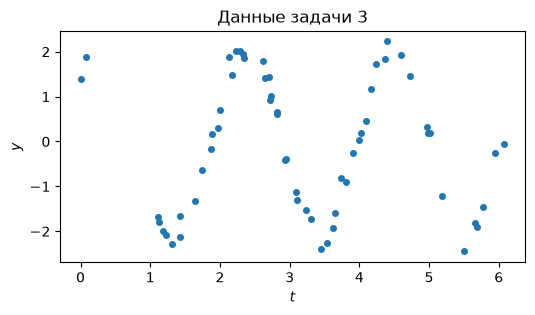

In [6]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 3")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

Модель A — безусловная NLP (нелинейный МНК), задача не выпуклая.

$f$ не меняется при $(x_1, x_3) \to (-x_1, x_3 + \pi)$. Поэтому вместе с минимумом $x^\ast$ минимумом будет и $\tilde x = (-x_1^\ast, x_2^\ast, x_3^\ast + \pi)$. В середине между ними $x_1 = 0$, модель нулевая, и $f = \tfrac12\sum_i y_i^2 > f^\ast$. У выпуклой функции значение в середине отрезка не больше среднего значений на концах, а здесь оно больше.

Кроме того, $f$ $2\pi$-периодична по $x_3$. Выпуклая функция, ограниченная на прямой, на ней постоянна, а $f$ по $x_3$ не постоянна.

Модель B — линейный МНК (безусловная QP), задача выпуклая.

Модель линейна по $x$: $\varphi_B = Mx$, у матрицы $M$ столбцы $\sin\omega t_i$ и $\cos\omega t_i$. Тогда $f(x) = \tfrac12\Vert Mx - y\Vert^2$ и $\nabla^2 f = M^\top M \succeq 0$. Столбцы $M$ линейно независимы, поэтому $M^\top M \succ 0$ и минимум единственный.

**Мультистарт (пункт 2)**

модель A: f по стартам [ 1.1393 63.8249  1.1393  1.1393  1.1393 61.4973 61.4973 64.2518  1.1393
 63.8249  1.1393  1.1393 61.4973  1.1393 64.2518  1.1393 61.6882  1.1393
 61.4973  1.1393]
  наименьшее f = 1.139273, к нему пришли 55% стартов
модель B: f по стартам [1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]
  наименьшее f = 1.140764, к нему пришли 100% стартов
для сравнения 0.5 * sum(y^2) = 64.42

лучшее решение A (амплитуда, частота, фаза): [-2.1014  2.9967 -2.4413]
решение B: [1.6234 1.3378] -> амплитуда 2.1036 , фаза 0.6892


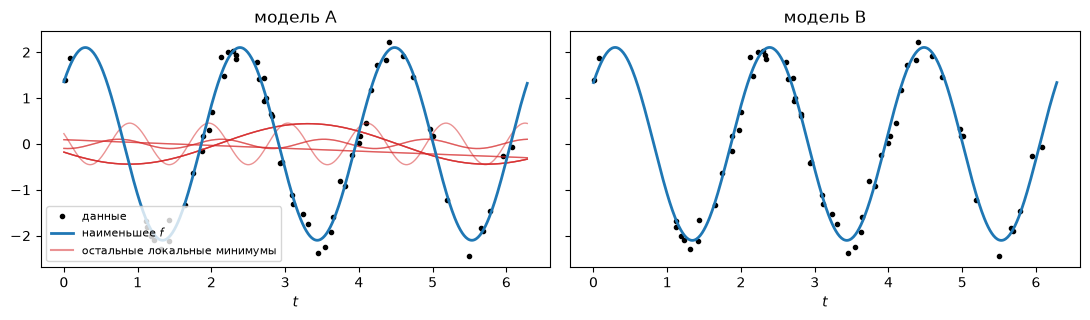

In [7]:
def f_A(x):
    return 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2)

def f_B(x):
    return 0.5 * np.sum((x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y) ** 2)

res_A = [minimize(f_A, s, method="BFGS") for s in starts]
res_B = [minimize(f_B, s[:2], method="BFGS") for s in starts]
F_A = np.array([r.fun for r in res_A])
F_B = np.array([r.fun for r in res_B])

for name, F in [("A", F_A), ("B", F_B)]:
    print(f"модель {name}: f по стартам", np.round(F, 4))
    print(f"  наименьшее f = {F.min():.6f}, к нему пришли {np.isclose(F, F.min(), rtol=1e-6).mean():.0%} стартов")
print(f"для сравнения 0.5 * sum(y^2) = {0.5 * np.sum(y**2):.2f}")

x_A, x_B = res_A[np.argmin(F_A)].x, res_B[np.argmin(F_B)].x
print("\nлучшее решение A (амплитуда, частота, фаза):", np.round(x_A, 4))
print("решение B:", np.round(x_B, 4), "-> амплитуда", round(np.hypot(*x_B), 4),
      ", фаза", round(np.arctan2(x_B[1], x_B[0]), 4))

model_A = lambda x, s: x[0] * np.sin(x[1] * s + x[2])
model_B = lambda x, s: x[0] * np.sin(omega * s) + x[1] * np.cos(omega * s)
ts = np.linspace(0, 2 * np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3), sharey=True)
for ax, name, res, F, model in [(axes[0], "A", res_A, F_A, model_A), (axes[1], "B", res_B, F_B, model_B)]:
    ax.plot(t, y, "o", ms=3, color="k", label="данные")
    for r in res:
        if not np.isclose(r.fun, F.min(), rtol=1e-6):
            ax.plot(ts, model(r.x, ts), color="tab:red", alpha=0.5, lw=1)
    ax.plot(ts, model(res[np.argmin(F)].x, ts), color="tab:blue", lw=2, label="наименьшее $f$")
    ax.set_title(f"модель {name}"); ax.set_xlabel("$t$")
axes[0].plot([], [], color="tab:red", alpha=0.5, label="остальные локальные минимумы")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**Объяснение (пункт 3)**

**Ответ:**

Модель B из всех 20 стартов приходит к одному значению $f \approx 1.1408$. Модель A приходит к наименьшему $f \approx 1.1393$ только из 11 стартов (55%), остальные застревают в локальных минимумах с $f \approx 61$–$64$. Это почти $\tfrac12\sum_i y_i^2 \approx 64$: при неверной частоте выгоднее всего маленькая амплитуда.

По главной теореме лекции у выпуклой задачи любой локальный минимум глобальный. B выпукла, поэтому BFGS из любого старта приходит в единственный минимум. A не выпукла, теорема к ней не применяется: по частоте много локальных минимумов, и результат зависит от старта.

Амплитуда и фаза из решения B: $x_1\sin\omega t + x_2\cos\omega t = R\sin(\omega t + \varphi)$ при $R = \sqrt{x_1^2 + x_2^2}$ и $\varphi = \operatorname{atan2}(x_2, x_1)$, это видно, если раскрыть синус суммы. Получаем $(R, \omega, \varphi) \approx (2.104,\ 3,\ 0.689)$, близко к истинным $(2,\ 3,\ 0.7)$.

У A наименьшее $f$ чуть меньше, потому что B — это A с частотой, зафиксированной на $3$. A минимизирует по большему множеству, поэтому её минимум не больше. A подстраивает частоту ($\approx 2.997$) под шум и выигрывает $0.0015$, около $0.1\%$. Лучшей задачей A от этого не становится: если частота известна, B решается из любого старта с гарантией, а A требует мультистарта и не гарантирует глобальный минимум.

## Задача 4. Множители Лагранжа (3 балла)

По 1 баллу за пункт. Обозначения — как в лекции 3: задача $\min f(x)$ при $g(x) = 0$, $h(x) \ge 0$; $L = f - \lambda^\top g - \mu^\top h$; система ККТ — $\nabla_x L = 0$, допустимость, $\mu \ge 0$, $\mu_i h_i = 0$.

**(а) Проекция на полупространство: две дороги к одному ответу** ★. Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$: $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$.

1. **Через условие лекции 2.** Из $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите
$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$
Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что условие выполнено для всех $y \in \Omega$.
2. **Через баланс сил лекции 3.** Запишите $h(x) = b - a^\top x \ge 0$ и условие $\nabla f = \mu \nabla h$. Получите ту же формулу и значение $\mu^\ast$; почему $\mu^\ast \ge 0$ ровно тогда, когда $p \notin \Omega$? Как $\mu^\ast$ связано с расстоянием от $p$ до $\Omega$?
3. **Цена.** Найдите $f^\ast(b)$ и проверьте, что $df^\ast / db = -\mu^\ast$. Объясните знак.

**(б) Собственные числа как касание** ★★. $A \in \mathbb{S}^n$, задача $\min$ (или $\max$) $x^\top A x$ при $\Vert x\Vert^2 = 1$.

1. Запишите условие касания $\nabla f = \lambda \nabla g$ и покажите, что его решения — ровно единичные собственные векторы $A$, а множитель $\lambda$ равен собственному числу и значению $f$ в этой точке. Выведите, что $\min = \lambda_n(A)$, $\max = \lambda_1(A)$ (почему минимум и максимум вообще существуют?). Сравните с задачей 2(в).
2. Для $A = \operatorname{diag}(1, 2, 3)$ перечислите все точки, где выполнено условие касания. Покажите, что $\pm e_2$ — ни минимум, ни максимум: сдвиньтесь по сфере в сторону $e_1$ и в сторону $e_3$. Какой вывод о системе ККТ для невыпуклых задач? Выпукла ли эта задача?
3. Замените ограничение на $\Vert x\Vert^2 = r$, $r > 0$. Найдите $f^\ast_{\min}(r)$ и $df^\ast_{\min}/dr$ и сравните с $\lambda$.

**(в) Водозаполнение** ★★★. Мощность $P > 0$ распределяется между $n$ каналами связи с уровнями шума $\alpha_i > 0$; пропускная способность канала с мощностью $x_i$ равна $\log(\alpha_i + x_i)$ (с точностью до константы). Задача:
$$\max_x \sum_{i=1}^n \log(\alpha_i + x_i) \quad\text{при}\quad \sum_i x_i = P,\ \ x_i \ge 0 .$$
1. Приведите задачу к виду $\min f$ и докажите, что она выпукла.
2. Выпишите систему ККТ и выведите решение
$$x_i^\ast = \max(0,\ w - \alpha_i),$$
где «уровень воды» $w$ определяется уравнением $\sum_i \max(0, w - \alpha_i) = P$. Почему у этого уравнения ровно одно решение? Объясните название: на что похожа картинка «дно $\alpha_i$ + налитая вода $x_i$»? Какие каналы не получают ничего и какой у них множитель?
3. Для $\alpha = (0.4,\ 0.8,\ 1.2,\ 2.0,\ 3.0)$ и $P = 2$ найдите $w$, $x^\ast$, $\lambda^\ast$ и $\mu^\ast$ **руками**, затем проверьте кодом (`minimize` с `method="SLSQP"` или бисекция по $w$) и нарисуйте картинку «сосудов».
4. На сколько вырастет суммарная пропускная способность, если добавить немного мощности? Ответьте через множитель и проверьте конечной разностью.

In [8]:
alpha = np.array([0.4, 0.8, 1.2, 2.0, 3.0])   # уровни шума в каналах, задача 4(в)
P = 2.0                                        # суммарная мощность

**(а)**

**Ответ:**

1. $x^\ast = p - \dfrac{a^\top p - b}{\Vert a\Vert^2}\, a$.

    $\nabla f(x) = x - p$.

    Точка $x^\ast$ лежит на границе. Если $a^\top x^\ast < b$, то при малом $\varepsilon > 0$ точка $y = x^\ast - \varepsilon(x^\ast - p)$ допустима, и условие даёт $-\varepsilon\Vert x^\ast - p\Vert^2 \ge 0$. Значит, $x^\ast = p$, но $p \notin \Omega$. Поэтому $a^\top x^\ast = b$.

    Для $v$ с $a^\top v = 0$ точки $x^\ast \pm v$ допустимы. Условие для них: $\pm(x^\ast - p)^\top v \ge 0$, то есть $(x^\ast - p)^\top v = 0$ для всех $v \perp a$. Значит, $x^\ast - p$ коллинеарен $a$: $x^\ast = p + s\,a$.

    Из $a^\top x^\ast = a^\top p + s\Vert a\Vert^2 = b$ получаем $s = -\dfrac{a^\top p - b}{\Vert a\Vert^2}$.

    Проверка для всех $y \in \Omega$: $(x^\ast - p)^\top(y - x^\ast) = s\,(a^\top y - b) \ge 0$, так как $s < 0$ и $a^\top y \le b$. Задача выпуклая, поэтому этого условия достаточно.

2. $\mu^\ast = \dfrac{a^\top p - b}{\Vert a\Vert^2} = \dfrac{\operatorname{dist}(p, \Omega)}{\Vert a\Vert}$.

    $h(x) = b - a^\top x$, $\nabla h = -a$. Из $\nabla f = \mu\nabla h$: $x^\ast - p = -\mu a$, то есть $x^\ast = p - \mu a$. При $\mu > 0$ ограничение активно, $a^\top x^\ast = b$, отсюда $a^\top p - \mu\Vert a\Vert^2 = b$ и получаем $\mu^\ast$. Формула для $x^\ast$ та же.

    $\mu^\ast > 0$ ровно тогда, когда $a^\top p > b$, то есть $p \notin \Omega$. Если $p \in \Omega$, формула дала бы $\mu < 0$, а стенка не может притягивать. Тогда ограничение неактивно, $x^\ast = p$ и $\mu^\ast = 0$.

    Расстояние $\Vert p - x^\ast\Vert = \mu^\ast\Vert a\Vert$. При $\Vert a\Vert = 1$ множитель равен расстоянию.

3. $df^\ast/db = -\mu^\ast$.

    $$f^\ast(b) = \tfrac12\Vert x^\ast - p\Vert^2 = \frac{(a^\top p - b)^2}{2\Vert a\Vert^2}, \qquad \frac{df^\ast}{db} = -\frac{a^\top p - b}{\Vert a\Vert^2} = -\mu^\ast .$$

    Знак минус: при увеличении $b$ ограничение ослабевает, $\Omega$ растёт и подходит к $p$, поэтому минимум уменьшается.

**(б)**

**Ответ:**

1. Решения условия касания — единичные собственные векторы, $\lambda$ — собственное число, $\min = \lambda_n(A)$, $\max = \lambda_1(A)$.

    $f = x^\top A x$, $g = \Vert x\Vert^2 - 1$, $\nabla f = 2Ax$, $\nabla g = 2x$. Условие касания $2Ax = 2\lambda x$, то есть $Ax = \lambda x$. При $\Vert x\Vert = 1$ это ровно единичные собственные векторы, а $\lambda$ — собственное число. Значение $f(x) = \lambda\, x^\top x = \lambda$.

    Минимум и максимум существуют: сфера замкнута и ограничена, а $f$ непрерывна. На сфере $\nabla g \ne 0$, поэтому в экстремуме касание выполнено. Значит, экстремальные значения — собственные числа: $\min = \lambda_n$, $\max = \lambda_1$. Это та же формула, что в 2(в), но выведенная через множитель.

2. Условие касания выполнено в $\pm e_1$, $\pm e_2$, $\pm e_3$, а $\pm e_2$ — седло. Задача не выпуклая.

    Собственные числа $1, 2, 3$ различны, поэтому подходят $\pm e_1$ ($\lambda = 1$, минимум), $\pm e_2$ ($\lambda = 2$) и $\pm e_3$ ($\lambda = 3$, максимум). Сдвинемся из $e_2$ по сфере:

    $$x = \cos\theta\,e_2 + \sin\theta\,e_1:\ f = 2 - \sin^2\theta < 2, \qquad x = \cos\theta\,e_2 + \sin\theta\,e_3:\ f = 2 + \sin^2\theta > 2 .$$

    В одну сторону $f$ убывает, в другую растёт, значит $e_2$ ни минимум, ни максимум. Для невыпуклых задач система ККТ только необходима: её решения надо перебрать и сравнить значения. Задача не выпуклая, потому что сфера — невыпуклое множество.

3. $f^\ast_{\min}(r) = r\lambda_n(A)$, $df^\ast_{\min}/dr = \lambda_n = \lambda$.

    При $\Vert x\Vert^2 = r$ запишем $x = \sqrt r\,u$, $\Vert u\Vert = 1$. Тогда $f = r\,u^\top A u$, и минимум равен $r\lambda_n$. Условие касания то же, $Ax = \lambda x$, и в минимуме $\lambda = \lambda_n$. Производная оптимума по $r$ равна множителю.

In [9]:
A4 = np.diag([1.0, 2.0, 3.0])
f4 = lambda x: x @ A4 @ x
print("собственные числа:", np.linalg.eigvalsh(A4))

e1, e2, e3 = np.eye(3)
thetas = np.linspace(-0.4, 0.4, 5)
print("из e2 в сторону e1:", np.round([f4(np.cos(th) * e2 + np.sin(th) * e1) for th in thetas], 4))
print("из e2 в сторону e3:", np.round([f4(np.cos(th) * e2 + np.sin(th) * e3) for th in thetas], 4))

def f_min(r):
    # мультистарт: задача невыпукла, SLSQP может остановиться в седле или максимуме
    runs = [minimize(f4, x0, method="SLSQP", tol=1e-12,
                     constraints=[{"type": "eq", "fun": lambda x: x @ x - r}]) for x0 in rng.standard_normal((5, 3))]
    return min(run.fun for run in runs)

h = 1e-3
print(f"\nf*_min(1) = {f_min(1.0):.6f}, f*_min(2) = {f_min(2.0):.6f}")
print(f"df*_min/dr при r = 1: конечная разность {(f_min(1 + h) - f_min(1 - h)) / (2 * h):.6f}, множитель lambda_3 = 1")

собственные числа: [1. 2. 3.]
из e2 в сторону e1: [1.8484 1.9605 2.     1.9605 1.8484]
из e2 в сторону e3: [2.1516 2.0395 2.     2.0395 2.1516]

f*_min(1) = 1.000000, f*_min(2) = 2.000000
df*_min/dr при r = 1: конечная разность 1.000000, множитель lambda_3 = 1


**(в)**

**Ответ:**

1. Задача выпуклая.

    $$\min_x\ -\sum_i \log(\alpha_i + x_i) \quad\text{при}\quad \sum_i x_i = P,\ \ x \ge 0 .$$

    $-\log u$ выпукла ($1/u^2 > 0$), от аффинной функции $u = \alpha_i + x_i$ она остаётся выпуклой, а сумма выпуклых выпукла. Гессиан $\operatorname{diag}\big(1/(\alpha_i + x_i)^2\big) \succ 0$, так что функция строго выпукла и решение единственное. Ограничения линейные, допустимое множество выпукло.

2. $x_i^\ast = \max(0,\ w - \alpha_i)$, где $w = -1/\lambda$.

    $L = -\sum_i \log(\alpha_i + x_i) - \lambda\big(\sum_i x_i - P\big) - \sum_i \mu_i x_i$. Система ККТ:

    $$-\frac{1}{\alpha_i + x_i} - \lambda - \mu_i = 0, \qquad \sum_i x_i = P, \quad x \ge 0, \quad \mu \ge 0, \quad \mu_i x_i = 0 .$$

    Из первого уравнения $\frac{1}{\alpha_i + x_i} = -\lambda - \mu_i > 0$, значит $\lambda < 0$. Обозначим $w = -1/\lambda$. Если $x_i > 0$, то $\mu_i = 0$ и $x_i = w - \alpha_i$, это возможно только при $\alpha_i < w$. Если $x_i = 0$, то $\mu_i = \frac1w - \frac1{\alpha_i} \ge 0$, то есть $\alpha_i \ge w$. Оба случая дают $x_i^\ast = \max(0, w - \alpha_i)$. Задача выпуклая, поэтому ККТ достаточны.

    Корень уравнения на $w$ один: $F(w) = \sum_i \max(0, w - \alpha_i)$ непрерывна, равна $0$ при $w \le \min_i \alpha_i$, дальше строго возрастает и уходит в бесконечность.

    Название: если поставить сосуды с дном на высоте $\alpha_i$ и налить в них воду объёмом $P$, вода установится на общем уровне $w$, и в сосуде $i$ будет слой $x_i = w - \alpha_i$. Каналы с дном выше уровня, то есть самые шумные, ничего не получают. У них $\mu_i = \frac1w - \frac1{\alpha_i} \ge 0$.

3. $w = \tfrac{22}{15}$, $x^\ast = \big(\tfrac{16}{15},\ \tfrac23,\ \tfrac4{15},\ 0,\ 0\big)$, $\lambda^\ast = -\tfrac{15}{22}$, $\mu^\ast = \big(0,\ 0,\ 0,\ \tfrac2{11},\ \tfrac{23}{66}\big)$.

    Если мощность получают $k$ самых тихих каналов, то $w = (P + \alpha_1 + \dots + \alpha_k)/k$, и должно быть $\alpha_k < w \le \alpha_{k+1}$. При $k = 1$: $w = 2.4 > 0.8$ — не подходит. При $k = 2$: $w = 1.6 > 1.2$ — не подходит. При $k = 3$: $w = 4.4/3 = 22/15 \approx 1.467$, и $1.2 < 1.467 \le 2$ — подходит.

    Отсюда $x^\ast \approx (1.067,\ 0.667,\ 0.267,\ 0,\ 0)$, $\lambda^\ast = -1/w \approx -0.682$, $\mu_4 = \tfrac{15}{22} - \tfrac12 \approx 0.182$, $\mu_5 = \tfrac{15}{22} - \tfrac13 \approx 0.348$. Код ниже даёт те же числа.

4. Пропускная способность растёт на $-\lambda^\ast = 1/w = \tfrac{15}{22} \approx 0.682$ на единицу мощности.

    Множитель ограничения $\sum_i x_i = P$ — это производная оптимума по $P$: $df^\ast/dP = \lambda^\ast$. Пропускная способность $C^\ast = -f^\ast$, поэтому $dC^\ast/dP = -\lambda^\ast$. Конечная разность в коде совпадает.

w = 1.466667  (руками 22/15 = 1.466667)
x*      = [1.066667 0.666667 0.266667 0.       0.      ]   сумма = 1.9999999999999996
lambda* = -0.681818   mu* = [0.       0.       0.       0.181818 0.348485]
SLSQP:   [1.066667 0.666667 0.266667 0.       0.      ]   расхождение с формулой 7.7e-08

dC*/dP: -lambda* = 0.681818, конечная разность = 0.681818


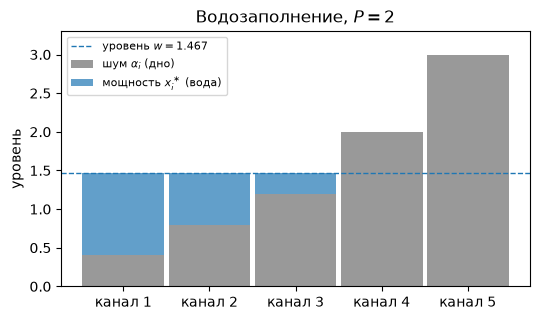

In [10]:
def water_level(alpha, P):
    # F(w) = sum max(0, w - alpha_i) - P: F < 0 при w = min alpha, F >= 0 при w = min alpha + P
    return brentq(lambda w: np.sum(np.maximum(0, w - alpha)) - P, alpha.min(), alpha.min() + P)

w = water_level(alpha, P)
x_star = np.maximum(0, w - alpha)
lam_star = -1 / w
mu_star = np.where(x_star > 0, 0, 1 / w - 1 / alpha)
print(f"w = {w:.6f}  (руками 22/15 = {22 / 15:.6f})")
print("x*      =", np.round(x_star, 6), "  сумма =", x_star.sum())
print("lambda* =", round(lam_star, 6), "  mu* =", np.round(mu_star, 6))

res = minimize(lambda x: -np.sum(np.log(alpha + x)), np.full(alpha.size, P / alpha.size), method="SLSQP", tol=1e-12,
               bounds=[(0, None)] * alpha.size, constraints=[{"type": "eq", "fun": lambda x: np.sum(x) - P}])
print("SLSQP:  ", np.round(res.x, 6), "  расхождение с формулой", f"{np.abs(res.x - x_star).max():.1e}")

def capacity(P_):
    return np.sum(np.log(alpha + np.maximum(0, water_level(alpha, P_) - alpha)))

h = 1e-4
print(f"\ndC*/dP: -lambda* = {-lam_star:.6f}, конечная разность = {(capacity(P + h) - capacity(P - h)) / (2 * h):.6f}")

i = np.arange(alpha.size)
plt.figure(figsize=(5.5, 3.3))
plt.bar(i, alpha, width=0.95, color="0.6", label=r"шум $\alpha_i$ (дно)")
plt.bar(i, x_star, width=0.95, bottom=alpha, color="tab:blue", alpha=0.7, label=r"мощность $x_i^\ast$ (вода)")
plt.axhline(w, color="tab:blue", ls="--", lw=1, label=f"уровень $w = {w:.3f}$")
plt.xticks(i, [f"канал {k + 1}" for k in i]); plt.ylabel("уровень"); plt.legend(fontsize=8, loc="upper left")
plt.ylim(0, 3.3); plt.title("Водозаполнение, $P = 2$"); plt.tight_layout(); plt.show()

## Бонус ★★★ (+1 балл). Максимум энтропии

Система может находиться в состояниях $i = 1, \dots, n$ с энергиями $E_i$. Какое распределение вероятностей $p$ наиболее «неопределённо» при известной средней энергии $\bar E$? Задача:
$$\max_p\ H(p) = -\sum_i p_i \log p_i \quad\text{при}\quad \sum_i p_i = 1,\ \ \sum_i p_i E_i = \bar E,\ \ p_i \ge 0$$
(с соглашением $0 \log 0 = 0$).

1. Докажите, что задача выпукла (в форме $\min -H$).
2. Без ограничения на энергию найдите решение через множитель Лагранжа.
3. С ограничением на энергию выпишите условия ККТ и покажите, что $p_i^\ast = e^{-\beta E_i} / Z$, $Z = \sum_j e^{-\beta E_j}$ (распределение Больцмана). Почему ограничения $p_i \ge 0$ оказываются неактивными? Как связан $\beta$ с множителями?
4. Для $E = (0, 1, 2, 3)$ и $\bar E = 1$ найдите $\beta$ численно (одно уравнение на одно число, `scipy.optimize.brentq`) и $p^\ast$. Почему $\beta > 0$? Проверьте конечной разностью, что $dH^\ast/d\bar E = \beta$ — это определение температуры из термодинамики, $\beta = 1/T$.

**Ответ:**

1. Задача выпуклая.

    $-H(p) = \sum_i p_i\log p_i$. У функции $u\log u$ вторая производная $1/u > 0$, она выпукла, а сумма выпуклых выпукла. Ограничения линейные, допустимое множество выпукло.

2. $p_i = 1/n$.

    $L = \sum_i p_i\log p_i - \lambda\big(\sum_i p_i - 1\big)$. Из $\log p_i + 1 - \lambda = 0$ все $p_i = e^{\lambda - 1}$ одинаковы, значит $p_i = 1/n$ и $\lambda = 1 - \log n$. Все $p_i > 0$, так что ограничения $p_i \ge 0$ неактивны.

3. $p_i^\ast = e^{-\beta E_i}/Z$, где $\beta = -\nu$, а $\nu$ — множитель ограничения на энергию.

    $L = \sum_i p_i\log p_i - \lambda\big(\sum_i p_i - 1\big) - \nu\big(\sum_i p_iE_i - \bar E\big) - \sum_i \mu_ip_i$. Условия ККТ — допустимость и

    $$\log p_i + 1 - \lambda - \nu E_i - \mu_i = 0, \qquad \mu \ge 0, \quad \mu_i p_i = 0 .$$

    Ограничения $p_i \ge 0$ неактивны, потому что производная $p\log p$ в нуле равна $-\infty$. Если какое-то $p_j = 0$, сдвинемся к допустимой точке $q$ со всеми $q_i > 0$: энтропия получит добавку $-\varepsilon q_j\log(\varepsilon q_j)$, которая растёт быстрее любого линейного $O(\varepsilon)$. Поэтому в оптимуме все $p_i > 0$ и $\mu = 0$.

    Тогда $p_i = e^{\lambda - 1}e^{\nu E_i}$. Обозначим $\beta = -\nu$. Из нормировки $e^{1-\lambda} = Z$, получаем $p_i^\ast = e^{-\beta E_i}/Z$ и $\lambda^\ast = 1 - \log Z$.

4. $\beta \approx 0.420$, $p^\ast \approx (0.421,\ 0.277,\ 0.182,\ 0.120)$.

    Средняя энергия $\langle E\rangle_\beta$ убывает по $\beta$: её производная равна $-\operatorname{Var}_\beta(E) < 0$. При $\beta = 0$ распределение равномерное и $\langle E\rangle_0 = 1.5$. Нужно $\bar E = 1 < 1.5$, поэтому $\beta > 0$.

    Множитель ограничения на энергию — производная оптимума по $\bar E$: $d(-H^\ast)/d\bar E = \nu$, то есть $dH^\ast/d\bar E = -\nu = \beta$. Конечная разность в коде совпадает с $\beta$.

In [11]:
E = np.array([0.0, 1.0, 2.0, 3.0])

def boltzmann(beta):
    weights = np.exp(-beta * E)
    return weights / weights.sum()

def solve_beta(E_bar):
    return brentq(lambda b: boltzmann(b) @ E - E_bar, -50, 50)

def entropy(p):
    return -np.sum(p * np.log(p))

beta = solve_beta(1.0)
p_star = boltzmann(beta)
print(f"beta = {beta:.6f}")
print("p*   =", np.round(p_star, 6), f"  сумма = {p_star.sum():.6f}, <E> = {p_star @ E:.6f}")

# сверка с прямой численной максимизацией энтропии
res = minimize(lambda p: np.sum(p * np.log(p)), np.full(E.size, 1 / E.size), method="SLSQP", tol=1e-12,
               bounds=[(1e-12, 1)] * E.size,
               constraints=[{"type": "eq", "fun": lambda p: p.sum() - 1}, {"type": "eq", "fun": lambda p: p @ E - 1.0}])
print("SLSQP:", np.round(res.x, 6))

h = 1e-4
dH = (entropy(boltzmann(solve_beta(1 + h))) - entropy(boltzmann(solve_beta(1 - h)))) / (2 * h)
print(f"\ndH*/dE_bar: конечная разность = {dH:.6f}, beta = {beta:.6f}")

beta = 0.419618
p*   = [0.421351 0.276953 0.182041 0.119655]   сумма = 1.000000, <E> = 1.000000
SLSQP: [0.421351 0.276953 0.182041 0.119655]

dH*/dE_bar: конечная разность = 0.419618, beta = 0.419618


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).